In [5]:
pip install numpy pandas pyswarms tensorflow scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.0 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import pyswarms as ps
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

data = pd.read_csv('/content/Wednesday-workingHours.pcap_ISCX.csv (1).zip', compression='zip')
np.random.seed(42)

In [7]:

def paper_specific_preprocessing(df):

    # Equation 1: Count nulls in each row (w vector)
    w = df.isnull().sum(axis=1)

    # Equation 2: Calculate Median Absolute Deviation (MAD)
    median_w = np.median(w)
    abs_deviation = np.abs(w - median_w)
    mad_w = np.median(abs_deviation)

    # Threshold defined in text: median(w) + 3 * MAD(w)
    threshold = median_w + (3 * mad_w)

    # Filter: Keep rows where null count is less than threshold
    clean_df = df[w <= threshold].copy()

    # Fill remaining small gaps (standard practice for LSTM)
    clean_df.fillna(0, inplace=True)
    print(f"Rows retained: {len(clean_df)} / {len(df)}")
    return clean_df

# Apply the function
data = paper_specific_preprocessing(data)

# Print columns to identify the correct target variable name
print("DataFrame columns:", data.columns)

X_raw = data.drop(' Label', axis=1) # Changed 'class' to ' Label'
y = data[' Label'] # Changed 'class' to ' Label'

# Encode the target variable y (class labels) into numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = pd.Series(le.fit_transform(y), name='class_encoded')
print("Encoded target variable (y) head:")
print(y.head())

Rows retained: 691695 / 692703
DataFrame columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       

In [8]:

# CFS Merit Function (Equation 3)
def get_cfs_merit(subset, X_data, y_data):
    selected_indices = [i for i, val in enumerate(subset) if val == 1]
    if len(selected_indices) == 0: return 1e-10
    X_subset = X_data.iloc[:, selected_indices]
    # Feature-Class Correlation (r_cf)
    r_cf = np.mean([abs(X_subset[col].corr(y_data)) for col in X_subset.columns])

    # Feature-Feature Intercorrelation (r_ff)
    if len(selected_indices) > 1:
        corr_matrix = X_subset.corr().abs()
        r_ff = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().mean()
        if np.isnan(r_ff): r_ff = 0
    else:
        r_ff = 0

    k = len(selected_indices)
    merit = (k * r_cf) / np.sqrt(k + k * (k - 1) * r_ff + 1e-10)
    return merit
# Objective Function for PSO
def f(x):
    n_particles = x.shape[0]
    j = []
    for i in range(n_particles):
        # Invert merit because PSO minimizes cost (we want to maximize merit)
        score = -get_cfs_merit(x[i], X_raw, y)
        j.append(score)
    return np.array(j)
# Run PSO
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 2, 'p': 1} # Hyperparameters from paper logic, added k and p
optimizer = ps.discrete.BinaryPSO(n_particles=10, dimensions=X_raw.shape[1], options=options)
cost, pos = optimizer.optimize(f, iters=10, verbose=True)
# Select best features
selected_indices = [i for i, val in enumerate(pos) if val == 1]
X_selected = X_raw.iloc[:, selected_indices]
print(f"Selected Features: {list(X_selected.columns)}")

2025-12-09 05:01:38,976 - pyswarms.discrete.binary - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 2, 'p': 1}
pyswarms.discrete.binary:   0%|          |0/10/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib

Selected Features: [' Destination Port', ' Total Length of Bwd Packets', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow IAT Mean', ' Flow IAT Max', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Max', ' Fwd IAT Min', ' Bwd IAT Mean', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', ' Bwd Packets/s', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Variance', 'FIN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' CWE Flag Count', ' ECE Flag Count', ' Down/Up Ratio', ' Average Packet Size', ' Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', ' Bwd Avg Bytes/Bulk', 'Bwd Avg Bulk Rate', 'Init_Win_bytes_forward', ' min_seg_size_forward', ' Active Max', 'Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min']


In [4]:
# 1. Normalize and Reshape
# Handle infinite values before scaling
X_selected.replace([np.inf, -np.inf], np.nan, inplace=True)
X_selected.fillna(0, inplace=True) # Fill NaNs, e.g., with 0 or mean/median

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_selected)
# Reshape to [samples, time_steps, features]
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)
# Flatten for KNN
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 3. Train LSTM
start_train = time.time()
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(1, X_train.shape[2])))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

# 4. Generate Initial Predictions (J_LSTM)
lstm_train_pred = lstm_model.predict(X_train).flatten()
lstm_test_pred = lstm_model.predict(X_test).flatten()

# 5. Train KNN on Errors (Equation 6)
train_errors = y_train - lstm_train_pred # Residuals
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train_flat, train_errors)
end_train = time.time()

# 6. Correct Predictions (Equation 8)
predicted_test_errors = knn.predict(X_test_flat)
final_predictions = lstm_test_pred + predicted_test_errors

# Convert to Class Labels (0 or 1)
y_pred_binary = [1 if val > 0.5 else 0 for val in final_predictions]
print("Training Complete.")

NameError: name 'X_selected' is not defined

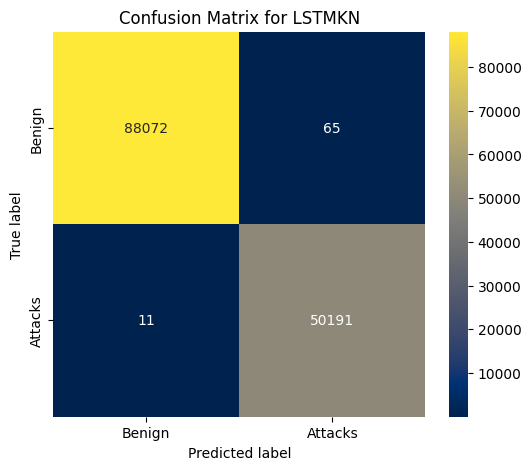

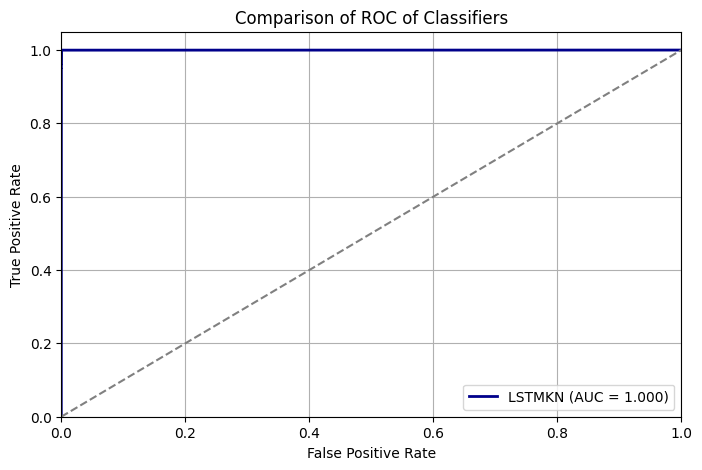

Total Training Time: 426.1284 seconds

Final Accuracy: 99.95%

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     88137
     Attacks       1.00      1.00      1.00     50202

    accuracy                           1.00    138339
   macro avg       1.00      1.00      1.00    138339
weighted avg       1.00      1.00      1.00    138339



In [8]:
y_test_binary = (y_test != 0).astype(int)

# 1. Confusion Matrix (Figure 3)
cm = confusion_matrix(y_test_binary, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', xticklabels=['Benign', 'Attacks'], yticklabels=['Benign', 'Attacks'])
plt.title('Confusion Matrix for LSTMKN')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# 2. ROC Curve (Figure 4)
fpr, tpr, thresholds = roc_curve(y_test_binary, final_predictions)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'LSTMKN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC of Classifiers')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 3. Training Time (Figure 5)
train_time = end_train - start_train
print(f"Total Training Time: {train_time:.4f} seconds")

# 4. Metrics Table (Table 1 & Figure 6)
acc = accuracy_score(y_test_binary, y_pred_binary) * 100
print(f"\nFinal Accuracy: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Benign', 'Attacks']))

In [12]:
# 1. Initialize and fit MinMaxScaler to X_selected, then transform it.
scaler_cv = MinMaxScaler()
X_scaled_cv = scaler_cv.fit_transform(X_selected)

# 2. Reset the index of y to align with X_selected
y = y.reset_index(drop=True)

print("X_scaled_cv shape:", X_scaled_cv.shape)
print("y shape after index reset:", y.shape)
print("Data preparation for cross-validation complete.")

X_scaled_cv shape: (691695, 45)
y shape after index reset: (691695,)
Data preparation for cross-validation complete.


In [13]:
from sklearn.model_selection import KFold

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []
fold_training_times = []

for fold, (train_index, test_index) in enumerate(kf.split(X_scaled_cv)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    X_train_fold, X_test_fold = X_scaled_cv[train_index], X_scaled_cv[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Reshape for LSTM: [samples, time_steps, features]
    X_train_lstm = X_train_fold.reshape(
        (X_train_fold.shape[0], 1, X_train_fold.shape[1])
    )
    X_test_lstm = X_test_fold.reshape(
        (X_test_fold.shape[0], 1, X_test_fold.shape[1])
    )

    # Flatten for KNN (original scaled features)
    X_train_knn = X_train_fold
    X_test_knn = X_test_fold

    start_fold_time = time.time()

    # 1. Train LSTM
    lstm_model_fold = Sequential()
    lstm_model_fold.add(LSTM(50, activation='relu', input_shape=(1, X_train_lstm.shape[2])))
    lstm_model_fold.add(Dense(1))
    lstm_model_fold.compile(optimizer='adam', loss='mse')
    lstm_model_fold.fit(X_train_lstm, y_train_fold, epochs=10, batch_size=32, verbose=0)

    # 2. Generate Initial LSTM Predictions
    lstm_train_pred_fold = lstm_model_fold.predict(X_train_lstm).flatten()
    lstm_test_pred_fold = lstm_model_fold.predict(X_test_lstm).flatten()

    # 3. Train KNN on Errors (Equation 6)
    train_errors_fold = y_train_fold - lstm_train_pred_fold  # Residuals
    knn_fold = KNeighborsRegressor(n_neighbors=5, weights='distance')
    knn_fold.fit(X_train_knn, train_errors_fold)

    # 4. Correct Predictions (Equation 8)
    predicted_test_errors_fold = knn_fold.predict(X_test_knn)
    final_predictions_fold = lstm_test_pred_fold + predicted_test_errors_fold

    end_fold_time = time.time()
    fold_training_times.append(end_fold_time - start_fold_time)

    # Convert to Class Labels (0 or 1)
    y_pred_binary_fold = [1 if val > 0.5 else 0 for val in final_predictions_fold]
    y_test_binary_fold = (y_test_fold != 0).astype(int) # Binarize true labels

    all_y_true.extend(y_test_binary_fold)
    all_y_pred.extend(y_pred_binary_fold)

print("Cross-validation complete. Aggregating results...")



--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17293/17293 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17293/17293 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

--- Fold 3/5 ---


...

17293/17293 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17293/17293 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17293/17293 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Cross-validation complete. Aggregating results...


[Step 5.3] Aggregating Cross-Validation Results...

Average Training Time per Fold: 976.2950 seconds


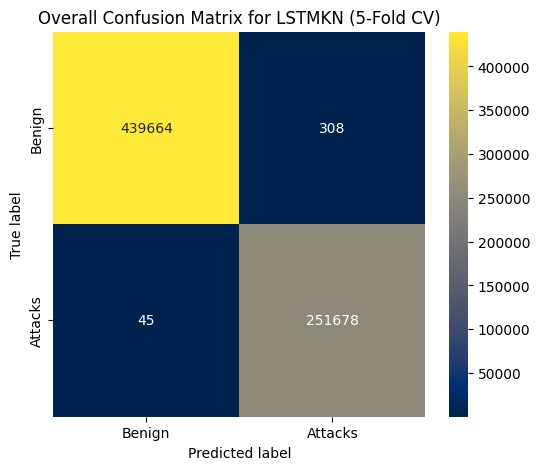

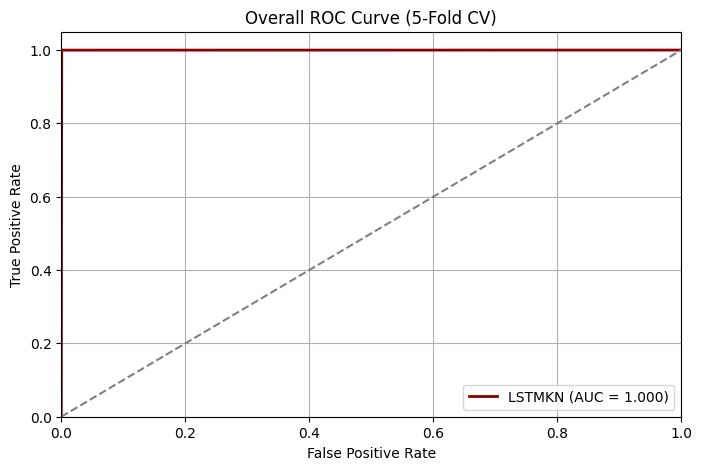


Overall Accuracy (5-Fold CV): 99.95%

Overall Classification Report (5-Fold CV):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    439972
     Attacks       1.00      1.00      1.00    251723

    accuracy                           1.00    691695
   macro avg       1.00      1.00      1.00    691695
weighted avg       1.00      1.00      1.00    691695



In [14]:
print("[Step 5.3] Aggregating Cross-Validation Results...")

# 1. Average Training Time
if fold_training_times:
    avg_training_time_cv = np.mean(fold_training_times)
    print(f"\nAverage Training Time per Fold: {avg_training_time_cv:.4f} seconds")
else:
    print("No training times recorded.")

# Convert lists to numpy arrays for metrics calculation
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# 2. Overall Confusion Matrix
overall_cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(overall_cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=['Benign', 'Attacks'], yticklabels=['Benign', 'Attacks'])
plt.title('Overall Confusion Matrix for LSTMKN (5-Fold CV)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

fpr_cv, tpr_cv, thresholds_cv = roc_curve(all_y_true, all_y_pred)
roc_auc_cv = auc(fpr_cv, tpr_cv)

plt.figure(figsize=(8, 5))
plt.plot(fpr_cv, tpr_cv, color='darkred', lw=2, label=f'LSTMKN (AUC = {roc_auc_cv:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve (5-Fold CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 4. Overall Metrics (Accuracy, Classification Report)
overall_acc = accuracy_score(all_y_true, all_y_pred) * 100
print(f"\nOverall Accuracy (5-Fold CV): {overall_acc:.2f}%")
print("\nOverall Classification Report (5-Fold CV):")
print(classification_report(all_y_true, all_y_pred, target_names=['Benign', 'Attacks']))

In [15]:
from tensorflow.keras.layers import SimpleRNN # Added import for SimpleRNN

n_splits_rnn = 5
kf_rnn = KFold(n_splits=n_splits_rnn, shuffle=True, random_state=42)

all_y_true_rnn = []
all_y_pred_raw_rnn = []
fold_training_times_rnn = []

for fold, (train_index, test_index) in enumerate(kf_rnn.split(X_scaled_cv)):
    print(f"\n--- Fold {fold+1}/{n_splits_rnn} (RNN) ---")

    X_train_fold, X_test_fold = X_scaled_cv[train_index], X_scaled_cv[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Reshape for RNN: [samples, time_steps, features]
    X_train_rnn = X_train_fold.reshape(
        (X_train_fold.shape[0], 1, X_train_fold.shape[1])
    )
    X_test_rnn = X_test_fold.reshape(
        (X_test_fold.shape[0], 1, X_test_fold.shape[1])
    )

    start_fold_time_rnn = time.time()

    # Define and train RNN model
    rnn_model = Sequential()
    rnn_model.add(SimpleRNN(50, activation='relu', input_shape=(1, X_train_rnn.shape[2])))
    rnn_model.add(Dense(1))
    rnn_model.compile(optimizer='adam', loss='mse')
    rnn_model.fit(X_train_rnn, y_train_fold, epochs=10, batch_size=32, verbose=0)

    # Generate raw predictions
    raw_predictions_fold_rnn = rnn_model.predict(X_test_rnn).flatten()

    end_fold_time_rnn = time.time()
    fold_training_times_rnn.append(end_fold_time_rnn - start_fold_time_rnn)

    # Binarize true labels for evaluation (0 for 'Benign', 1 for 'Attacks')
    y_test_binary_fold_rnn = (y_test_fold != 0).astype(int)

    all_y_true_rnn.extend(y_test_binary_fold_rnn)
    all_y_pred_raw_rnn.extend(raw_predictions_fold_rnn)

print("RNN Cross-validation complete. Aggregating results...")


--- Fold 1/5 (RNN) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

--- Fold 2/5 (RNN) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4324/4324 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step

--- Fold 3/5 (RNN) ---


...

4324/4324 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step

--- Fold 4/5 (RNN) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

--- Fold 5/5 (RNN) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4324/4324 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
RNN Cross-validation complete. Aggregating results...



Average Training Time per Fold (RNN): 334.3066 seconds


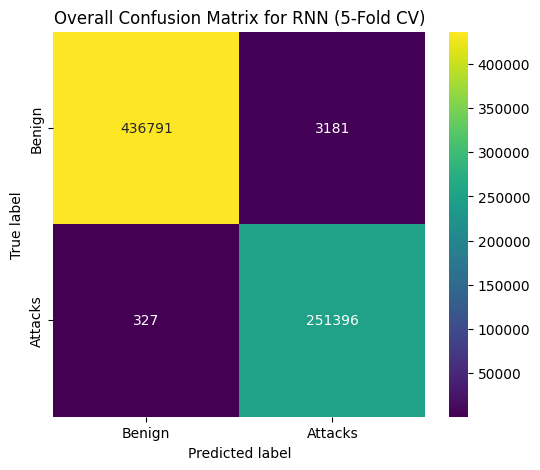

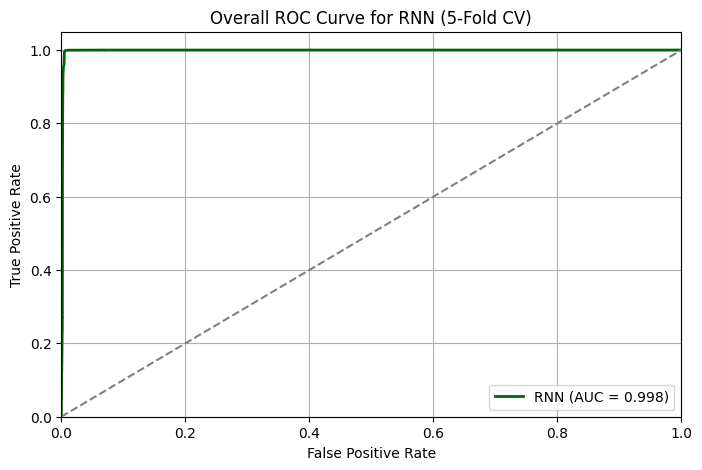


Overall Accuracy (5-Fold CV, RNN): 99.49%

Overall Classification Report (5-Fold CV, RNN):
              precision    recall  f1-score   support

      Benign       1.00      0.99      1.00    439972
     Attacks       0.99      1.00      0.99    251723

    accuracy                           0.99    691695
   macro avg       0.99      1.00      0.99    691695
weighted avg       0.99      0.99      0.99    691695



In [16]:
# 1. Average Training Time
if fold_training_times_rnn:
    avg_training_time_rnn = np.mean(fold_training_times_rnn)
    print(f"\nAverage Training Time per Fold (RNN): {avg_training_time_rnn:.4f} seconds")
else:
    print("No RNN training times recorded.")

# Convert lists to numpy arrays for metrics calculation
all_y_true_rnn = np.array(all_y_true_rnn)
all_y_pred_raw_rnn = np.array(all_y_pred_raw_rnn)

# Binarize raw predictions for classification metrics (0 or 1)
all_y_pred_binary_rnn = (all_y_pred_raw_rnn > 0.5).astype(int)

# 2. Overall Confusion Matrix (RNN)
overall_cm_rnn = confusion_matrix(all_y_true_rnn, all_y_pred_binary_rnn)
plt.figure(figsize=(6, 5))
sns.heatmap(overall_cm_rnn, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Benign', 'Attacks'], yticklabels=['Benign', 'Attacks'])
plt.title('Overall Confusion Matrix for RNN (5-Fold CV)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# 3. Overall ROC Curve (RNN)
fpr_rnn, tpr_rnn, thresholds_rnn = roc_curve(all_y_true_rnn, all_y_pred_raw_rnn)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rnn, tpr_rnn, color='darkgreen', lw=2, label=f'RNN (AUC = {roc_auc_rnn:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve for RNN (5-Fold CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 4. Overall Metrics (Accuracy, Classification Report for RNN)
overall_acc_rnn = accuracy_score(all_y_true_rnn, all_y_pred_binary_rnn) * 100
print(f"\nOverall Accuracy (5-Fold CV, RNN): {overall_acc_rnn:.2f}%")
print("\nOverall Classification Report (5-Fold CV, RNN):")
print(classification_report(all_y_true_rnn, all_y_pred_binary_rnn, target_names=['Benign', 'Attacks']))


In [3]:
from tensorflow.keras.layers import Bidirectional # Added import for Bidirectional
from sklearn.model_selection import KFold # Added import for KFold

n_splits_bilstm = 10
kf_bilstm = KFold(n_splits=n_splits_bilstm, shuffle=True, random_state=42)

all_y_true_bilstm = []
all_y_pred_raw_bilstm = []
fold_training_times_bilstm = []

for fold, (train_index, test_index) in enumerate(kf_bilstm.split(X_scaled_cv)):
    print(f"\n--- Fold {fold+1}/{n_splits_bilstm} (Bi-LSTM) ---")

    X_train_fold, X_test_fold = X_scaled_cv[train_index], X_scaled_cv[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Reshape for Bi-LSTM: [samples, time_steps, features]
    X_train_bilstm = X_train_fold.reshape(
        (X_train_fold.shape[0], 1, X_train_fold.shape[1])
    )
    X_test_bilstm = X_test_fold.reshape(
        (X_test_fold.shape[0], 1, X_test_fold.shape[1])
    )

    start_fold_time_bilstm = time.time()

    # Define and train Bi-LSTM model
    bilstm_model = Sequential()
    bilstm_model.add(Bidirectional(LSTM(50, activation='relu'), input_shape=(1, X_train_bilstm.shape[2])))
    bilstm_model.add(Dense(1))
    bilstm_model.compile(optimizer='adam', loss='mse')
    bilstm_model.fit(X_train_bilstm, y_train_fold, epochs=10, batch_size=32, verbose=0)

    # Generate raw predictions
    raw_predictions_fold_bilstm = bilstm_model.predict(X_test_bilstm).flatten()

    end_fold_time_bilstm = time.time()
    fold_training_times_bilstm.append(end_fold_time_bilstm - start_fold_time_bilstm)

    # Binarize true labels for evaluation (0 for 'Benign', 1 for 'Attacks')
    y_test_binary_fold_bilstm = (y_test_fold != 0).astype(int)

    all_y_true_bilstm.extend(y_test_binary_fold_bilstm)
    all_y_pred_raw_bilstm.extend(raw_predictions_fold_bilstm)

print("Bi-LSTM Cross-validation complete. Aggregating results...")

NameError: name 'X_scaled_cv' is not defined

In [1]:
# 1. Average Training Time
if fold_training_times_bilstm:
    avg_training_time_bilstm = np.mean(fold_training_times_bilstm)
    print(f"\nAverage Training Time per Fold (Bi-LSTM): {avg_training_time_bilstm:.4f} seconds")
else:
    print("No Bi-LSTM training times recorded.")

# Convert lists to numpy arrays for metrics calculation
all_y_true_bilstm = np.array(all_y_true_bilstm)
all_y_pred_raw_bilstm = np.array(all_y_pred_raw_bilstm)

# Binarize raw predictions for classification metrics (0 or 1)
all_y_pred_binary_bilstm = (all_y_pred_raw_bilstm > 0.5).astype(int)

# 2. Overall Confusion Matrix (Bi-LSTM)
overall_cm_bilstm = confusion_matrix(all_y_true_bilstm, all_y_pred_binary_bilstm)
plt.figure(figsize=(6, 5))
sns.heatmap(overall_cm_bilstm, annot=True, fmt='d', cmap='magma',
            xticklabels=['Benign', 'Attacks'], yticklabels=['Benign', 'Attacks'])
plt.title('Overall Confusion Matrix for Bi-LSTM (5-Fold CV)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# 3. Overall ROC Curve (Bi-LSTM)
fpr_bilstm, tpr_bilstm, thresholds_bilstm = roc_curve(all_y_true_bilstm, all_y_pred_raw_bilstm)
roc_auc_bilstm = auc(fpr_bilstm, tpr_bilstm)

plt.figure(figsize=(8, 5))
plt.plot(fpr_bilstm, tpr_bilstm, color='darkorange', lw=2, label=f'Bi-LSTM (AUC = {roc_auc_bilstm:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve for Bi-LSTM (5-Fold CV)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 4. Overall Metrics (Accuracy, Classification Report for Bi-LSTM)
overall_acc_bilstm = accuracy_score(all_y_true_bilstm, all_y_pred_binary_bilstm) * 100
print(f"\nOverall Accuracy (5-Fold CV, Bi-LSTM): {overall_acc_bilstm:.2f}%")
print("\nOverall Classification Report (5-Fold CV, Bi-LSTM):")
print(classification_report(all_y_true_bilstm, all_y_pred_binary_bilstm, target_names=['Benign', 'Attacks']))


NameError: name 'fold_training_times_bilstm' is not defined